In [ ]:
# Imports Required
import pandas as pd, matplotlib.pyplot as plt , matplotlib.image as mpimg

## Premier League Match Outcome Prediction & Season Simulation


This project builds a probabilistic machine learning system to predict
Home / Draw / Away outcomes for Premier League matches, with a specific
focus on uncertainty and draw modeling.

Rather than predicting a single outcome, the model outputs calibrated
probabilities and uses them to simulate full league seasons.

The emphasis of this project is not just predicting outcomes, but quantifying uncertainty and propagating it to season-level conclusions.

### Data Overview

The dataset consists of historical Premier League match results from the 2018/19 to 2024/25 seasons, using match-level observations. Data from the 2018/19 to 2022/23 seasons is used for model training, the 2023/24 season for calibration and validation, and the 2024/25 season for final evaluation. Only information available prior to each fixture is included to prevent data leakage. The prediction target is the full-time result (Home win, Draw, Away win).

Features are grouped into team form (e.g., rolling points per game and goals), relative team strength (goal difference and comparative metrics), and match context. Draws are inherently difficult to predict due to their lower frequency and the small performance margins that typically separate the teams involved.

### Modeling Approach 

Rather than producing a single class prediction, the model outputs a full probability distribution over match outcomes (Home / Draw / Away). This enables downstream analysis such as expected points, season simulations, and uncertainty-aware decision making.

Tree-based gradient boosting models are particularly suitable for this task due to their ability to capture non-linear interactions between team strength, form, and contextual match features. However, given the inherent difficulty and class imbalance associated with predicting draws, multiple modeling approaches are evaluated.

Models Used:

- Baseline (Always Home Win)
A naive benchmark used to highlight the limitations of accuracy-based evaluation in imbalanced multi-class settings.

- Logistic Regression
Serves as an interpretable baseline to understand linear feature effects and establish a calibrated probability reference. While argmax predictions rarely select draws, the model provides reasonably calibrated draw probabilities.

- XGBoost (Uncalibrated)
Introduced to capture non-linear feature interactions and asymmetric home/away effects. Class weighting is applied to penalize draw misclassification more heavily, resulting in a substantial increase in draw recall. However, this comes at the cost of overconfident probability estimates, as reflected by higher ECE and Brier scores.

- XGBoost (Calibrated)
Probability calibration is applied using Platt scaling to correct overconfidence. Calibration significantly improves probability reliability (lower ECE and Brier scores), although draw recall under an argmax decision rule decreases as the model becomes more conservative.

Class Imbalance and Evaluation Considerations:

Match outcomes are inherently imbalanced, with home and away wins occurring significantly more often than draws. As a result, accuracy alone is an insufficient evaluation metric, as a model can achieve strong accuracy by favoring the majority classes while systematically underpredicting draws. For this reason, evaluation focuses on class-specific performance and probability-based metrics, which provide a more informative assessment of model behavior under imbalance.



### Probability Calibration

While tree-based models such as XGBoost are effective at capturing non-linear interactions,
they are known to produce poorly calibrated probability estimates. In the context of football
match prediction—where probabilities are used for expected points, simulations, and downstream
decision-making—overconfident probabilities can lead to misleading conclusions.

A model is considered well-calibrated if outcomes predicted with probability *p* occur
approximately *p* percent of the time. Accuracy-based metrics alone are insufficient to
assess this property.

To address this, post-hoc probability calibration is applied using **Platt scaling** on a
held-out calibration set. This approach adjusts the predicted probability distribution
without retraining the underlying model, preserving relative class rankings while improving
probability reliability.

Calibration quality is evaluated using:
- Expected Calibration Error (ECE)
- Brier Score
- Reliability Curves

Evaluation Strategy:

- Model performance is assessed using metrics aligned with probabilistic modeling objectives
- Log Loss to evaluate overall probability quality
- Draw Recall to measure minority-class sensitivity
- Expected Calibration Error (ECE) and Brier Score to quantify probability reliability
- Reliability Curves to visually assess over- and under-confidence
- Confusion Matrix to analyze misclassification patterns under argmax decisions
- Accuracy is intentionally de-emphasized, as it fails to capture probability quality and is misleading in the presence of class imbalance.

In [ ]:
metrics_summary = pd.read_csv('C:/Users/Pratik/DS/premier-league-ml/reports/tables/model_metrics_summary.csv',index_col=False).reset_index(drop=True)
metrics_summary

,Model,Accuracy,Log Loss,Draw Recall,ECE (Draw),Brier (Draw)
0,Baseline (Always Home),0.407895,21.341637,0.000000,NaN,NaN
1,Logistic Regression,0.492105,1.014869,0.000000,0.045716,0.186211
2,XGBoost,0.465789,1.044432,0.193548,0.059655,0.191685
3,XGBoost Calibrated,0.478947,1.025525,0.096774,0.033384,0.184794


- The baseline model predicts every match as a home win. Although this results in high accuracy, it has very poor log loss and never predicts draws, leading to zero draw recall and no draw-specific ECE or Brier score.

- Logistic regression shows lower accuracy than the baseline but a large improvement in log loss. While it still never predicts draws as the top class, its ECE indicates reasonable calibration of draw probabilities, with moderate error reflected in the Brier score.

- Uncalibrated XGBoost increases draw recall to 19%, indicating active draw prediction, but suffers from poor calibration. Higher ECE and the worst Brier score suggest overconfidence in draw probabilities.

- Calibrated XGBoost achieves the best calibration, with the lowest ECE and Brier score. Draw recall decreases to 9%, reflecting reduced overconfidence and more reliable probability estimates.

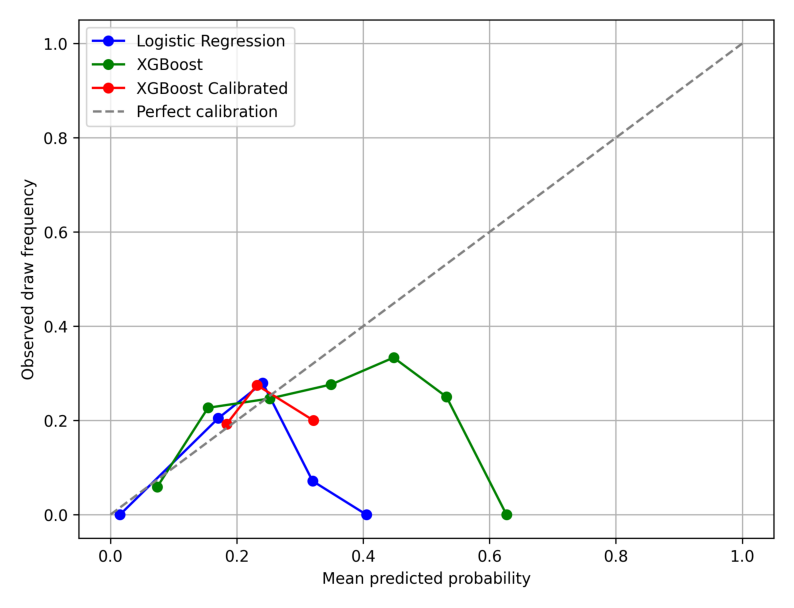

In [28]:
img_2 = mpimg.imread("../reports/figures/reliability_curve_draws_comparison.png")
plt.figure(figsize=(10, 8))
plt.imshow(img_2)
plt.axis("off")
plt.show()

The reliability curves show that both logistic regression and uncalibrated XGBoost become overconfident at higher predicted draw probabilities, assigning probabilities that exceed the observed draw frequency. After calibration, XGBoost still shows mild overconfidence but aligns more closely with the observed outcomes, indicating a clear improvement in probability calibration.

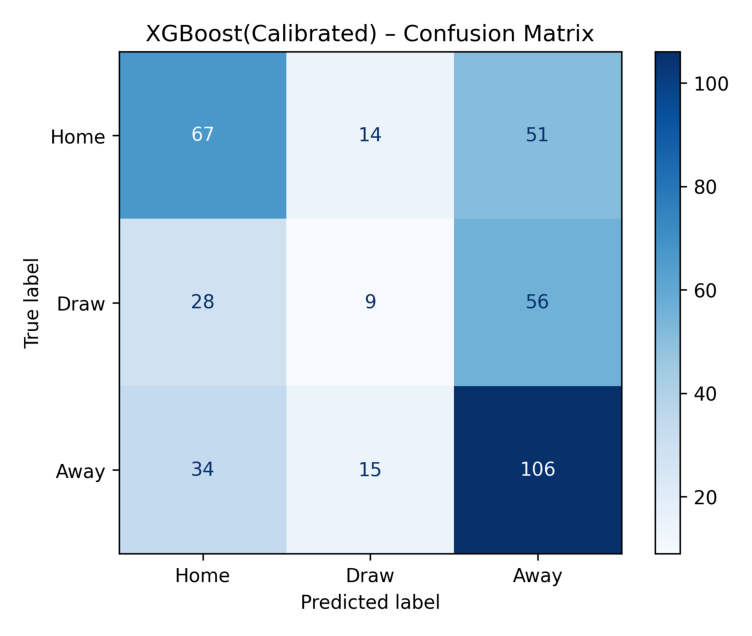

In [ ]:
img = mpimg.imread("../reports/figures/CM_XGBoost_Calibrated.png")
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

- The calibrated XGBoost model predicts Home and Away outcomes reliably, with strong performance on Away results (106 correct predictions).
- Draws remain difficult to identify, with only 9 correctly predicted; most true draws are misclassified as Away (56) or Home (28).
- The model shows a bias toward Away predictions, especially in uncertain cases across all true classes.
- Calibration improves the quality and reliability of predicted probabilities (lower ECE and Brier), but has limited impact on draw recall under an argmax decision rule.

Overall, the model is better suited for probability-based decision making than for direct classification of draws.

### Expected Points Table

- Inputs:
For each match, our model predicted the probabilities of a home win (P_Home), a draw (P_Draw), and an away win (P_Away).

- Formula:
Expected points for each team in a match were calculated as:

    - xPts Home = 3 × P(Home) + 1 × P(Draw)
    - xPts Away = 3 × P(Away) + 1 × P(Draw)

- Aggregation:
Match-level expected points were summed across all home and away games to produce season-level expected points for each team.

- Purpose / Use:
These totals form the expected league table, which can be compared with actual points to identify over- or under-performance.

Because expected points are computed directly from predicted probabilities, probability calibration is critical to avoid systematically over- or under-estimating team performance.

In [ ]:
xpts_df = pd.read_csv('C:/Users/Pratik/DS/premier-league-ml/reports/tables/league_table_expected_vs_actual.csv',index_col=False).reset_index(drop=True)
xpts_df

,Position,Team,xPts,ActualPts,Difference
0,1,Arsenal,68.747348,74,-5.252652
1,2,Man City,65.299175,71,-5.700825
2,3,Liverpool,64.359979,84,-19.640021
3,4,Bournemouth,58.031495,56,2.031495
4,5,Newcastle,56.098552,66,-9.901448
5,6,Chelsea,55.989253,69,-13.010747
6,7,Crystal Palace,55.776279,53,2.776279
7,8,Nott'm Forest,54.050198,65,-10.949802
8,9,Brentford,53.700192,56,-2.299808
9,10,Tottenham,53.643293,38,15.643293


- Arsenal’s xPts (~68.7) is lower than their actual points (74), suggesting overperformance relative to underlying match probabilities, potentially driven by strong finishing, late-game execution, or favorable variance.

- Tottenham’s xPts (~53.6) exceeds their actual points (38), indicating significant underperformance relative to expected outcomes, which may reflect inefficiencies, defensive lapses, or unfavorable variance over the season.

Expected points (xPts) measure a team's performance based on underlying stats like goals scored & conceded, reduce the influence of luck and finishing variance. Unlike actual points, xPts better reflect true quality and are more reliable for predicting future results


### Monte Carlo Season Simulation

- To translate match-level outcome probabilities into season long projections, a Monte Carlo simulation approach is employed. This method simulates full seasons by repeated random sampling of match results according to predicted probabilities, capturing the inherent randomness and uncertainty of football outcomes.

- This approach captures uncertainty and variability that single expected point estimates cannot, revealing range of possible outcomes.

- By aggregating these simulations, we estimate key season metrics such as expected points, position probabilities, and risks of relegation or title wins for each team. This provides a richer, uncertainty-aware perspective on team performance beyond single-match predictions.

- The table below summarizes the simulation results, showing expected points, standard deviation of points, and probabilities of finishing as champions, qualifying for the top four, or facing relegation for the top 20 teams.

- All results are estimated from 10,000 simulated seasons, where each match outcome is sampled according to the calibrated model probabilities.

- The standard deviation of points quantifies season-to-season volatility. Teams with similar expected points but higher standard deviation are more sensitive to randomness, injuries, or close-match variance.

In [ ]:
monte_df = pd.read_csv('C:/Users/Pratik/DS/premier-league-ml/reports/tables/monte_carlo_season_summary.csv',index_col=False).reset_index(drop=True)
monte_df.index = range(1, len(monte_df) + 1)
monte_df.index.name = 'Position'
monte_df

,Unnamed: 0,Expected_Points,Std_Points,Title_Prob,Top4_Prob,Relegation_Prob
Position,,,,,,
1,Arsenal,68.7693,8.068803,0.3593,0.7800,0.0003
2,Man City,65.3959,7.927146,0.1975,0.6415,0.0012
3,Liverpool,64.3564,8.058987,0.1633,0.5904,0.0029
4,Bournemouth,58.0534,8.060784,0.0441,0.2878,0.0199
5,Newcastle,56.1738,8.004949,0.0234,0.2075,0.0315
6,Chelsea,56.0628,8.025304,0.0253,0.2056,0.0303
7,Crystal Palace,55.7278,8.096620,0.0263,0.2004,0.0333
8,Nott'm Forest,54.0183,8.005959,0.0137,0.1416,0.0530
9,Tottenham,53.6538,7.965808,0.0138,0.1331,0.0549


- Arsenal shows the highest expected points and the highest title probability, indicating both strong underlying quality and consistent performance across simulations.
- Tottenham’s expected points are mid-table, but a relatively high standard deviation suggests volatile outcomes, explaining the large gap between expected and actual results
- Lower-table teams exhibit low title/top-4 probabilities but meaningful relegation risk, emphasizing how uncertainty compounds over a full season.


Monte Carlo simulation transforms calibrated match probabilities into a full distribution of season outcomes, allowing risk-aware evaluation of team performance beyond single-point estimates like expected points.

### Visual Comparisons (Big 6)

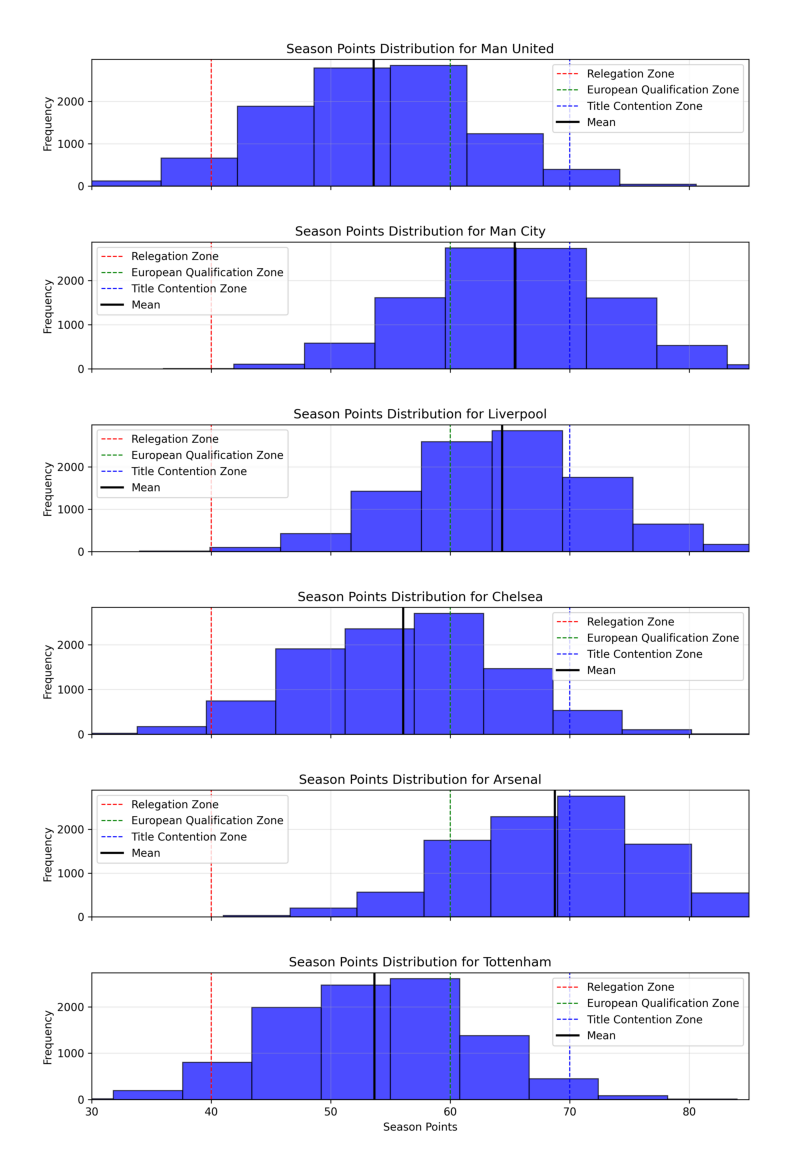

In [16]:
big_6_hist = mpimg.imread("../reports/figures/big_6_season_points_histograms.png")
plt.figure(figsize=(20, 15))
plt.imshow(big_6_hist)
plt.axis("off")
plt.show()

- These distributions show the full range of season outcomes for Big 6 teams across simulated seasons. Wider distributions indicate higher uncertainty, while narrower distributions reflect consistent performance.
- The mean line represents expected points, while the spread illustrates realistic upside and downside scenarios.
- This visualization makes uncertainty tangible, showing why two teams with similar expected points can experience very different seasons.

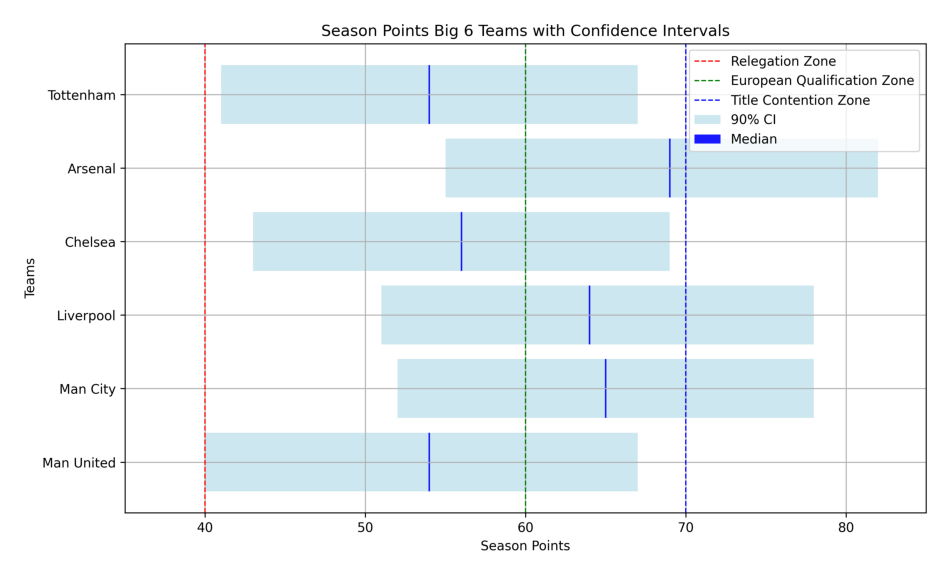

In [18]:
big_6_pts = mpimg.imread("../reports/figures/big_6_season_points_ci.png")
plt.figure(figsize=(12, 10))
plt.imshow(big_6_pts)
plt.axis("off")
plt.show()

The confidence intervals summarize the central 90% of simulated season outcomes.
Teams with overlapping intervals may be statistically indistinguishable despite different league finishes, emphasizing the limits of single-season rankings.

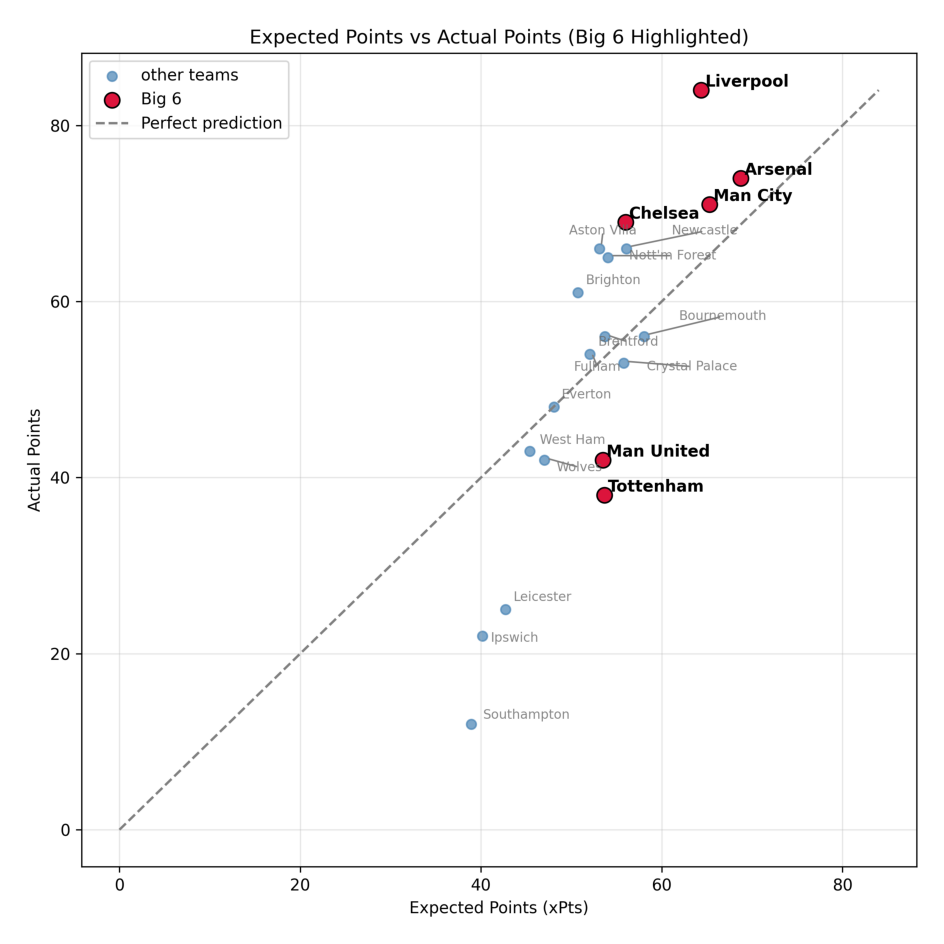

In [25]:
xpts_vs_actual_scatter = mpimg.imread("../reports/figures/xpts_vs_actual_scatter.png")
plt.figure(figsize=(15, 12))
plt.imshow(xpts_vs_actual_scatter)
plt.axis("off")
plt.show()

- The scatter plot compares model-derived expected points (xPts) with actual season outcomes. Team above the horizontal line overperformed relative to performance, while teams below underperformed.
- This highlights role of variance, finishing efficieny & game state randomness that xPts aims to smooth out.
- Persistent deviations from the diagonal may indicate structural strengths or weaknesses not fully captured by match-level features.

### Key Takeaways
- Logistic Regression provides stable but conservative probability estimates and rarely predicts draws as the most likely outcome, highlighting it's limitations in modelling overlapping outcome distributions.
- Uncalibrated XGBoost substantially increases draw recall but exhibits significant overconfidence, resulting in unreliable probability estimates.
- Probability calibration (Platt scaling) improves reliability metrics (ECE and Brier score), producing better-aligned probabilities even at the cost of lower draw recall under an argmax decision rule.
- Draw outcomes require explicit modeling and careful probability interpretation, as they represent the most ambiguous and least separable class.
- Season outcomes should be treated as distributions rather than point estimates, motivating the use of expected points and Monte Carlo simulation.

### Limitations & Next Steps

- The model does not incorporate player-level information such as injuries, squad rotation, or transfers.
- Fixture congestion and rest effects are not explicitly modeled.
- No time-decay weighting is applied; historical matches are treated uniformly.
- Analysis is limited to a single league and season.
- Expected goals (xG/xGA) and shot-quality metrics are not included.

**Future extensions could include:**

- Time-decayed feature weighting to emphasize recent form
- Incorporation of xG/xGA and